In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")

In [5]:
# файлы в директ
import os
print(os.listdir())

['.config', 'train.csv', 'sample_data']


In [7]:
sample_data = pd.read_csv('train.csv')
print(sample_data.shape)
print(sample_data.head())

(8693, 14)
  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4       

In [8]:
# Просмотр типов всех колонок
sample_data.dtypes

,0
PassengerId,object
HomePlanet,object
CryoSleep,object
Cabin,object
Destination,object
Age,float64
VIP,object
RoomService,float64
FoodCourt,float64
ShoppingMall,float64


In [9]:
# Количество пропусков в каждом столбце
sample_data.isnull().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


In [10]:
sample_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [11]:
total_count = sample_data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 8693


In [12]:
#  процент пропусков
missing_percent = (sample_data.isnull().sum() / len(sample_data)) * 100
print(missing_percent.sort_values(ascending=False))

# Затем обрабатывайте:
# Траты - заполняем 0
expenses = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
sample_data[expenses] = sample_data[expenses].fillna(0)

# Age - заполняем медианой
sample_data['Age'] = sample_data['Age'].fillna(sample_data['Age'].median())

# HomePlanet, Destination - заполняем модой
sample_data['HomePlanet'] = sample_data['HomePlanet'].fillna(sample_data['HomePlanet'].mode()[0])
sample_data['Destination'] = sample_data['Destination'].fillna(sample_data['Destination'].mode()[0])

# CryoSleep и VIP (bool) - заполняем False
sample_data['CryoSleep'] = sample_data['CryoSleep'].fillna(False)
sample_data['VIP'] = sample_data['VIP'].fillna(False)

# Cabin - заполняем Unknown
sample_data['Cabin'] = sample_data['Cabin'].fillna('Unknown')

# Проверка
print(sample_data.isnull().sum().sum())  # должно быть 0

CryoSleep       2.496261
ShoppingMall    2.392730
VIP             2.335212
HomePlanet      2.312205
Name            2.300702
Cabin           2.289198
VRDeck          2.162660
Spa             2.105142
FoodCourt       2.105142
Destination     2.093639
RoomService     2.082135
Age             2.059128
PassengerId     0.000000
Transported     0.000000
dtype: float64
200


/tmp/ipykernel_410/3729340303.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample_data['CryoSleep'] = sample_data['CryoSleep'].fillna(False)
/tmp/ipykernel_410/3729340303.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample_data['VIP'] = sample_data['VIP'].fillna(False)


In [13]:

data_num = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']


<Figure size 1200x800 with 0 Axes>

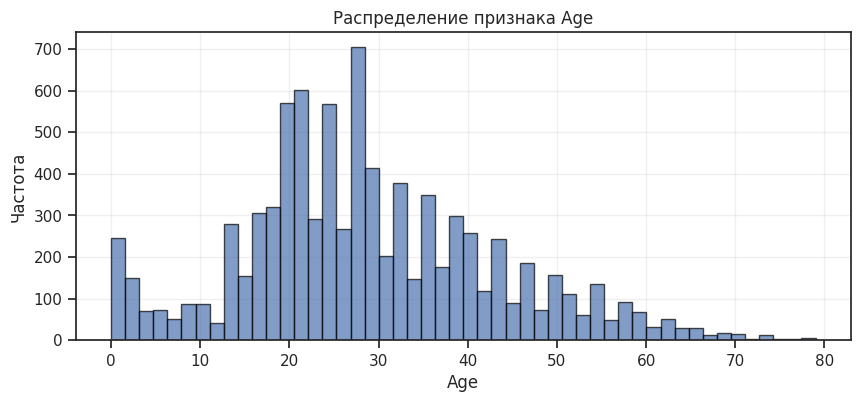

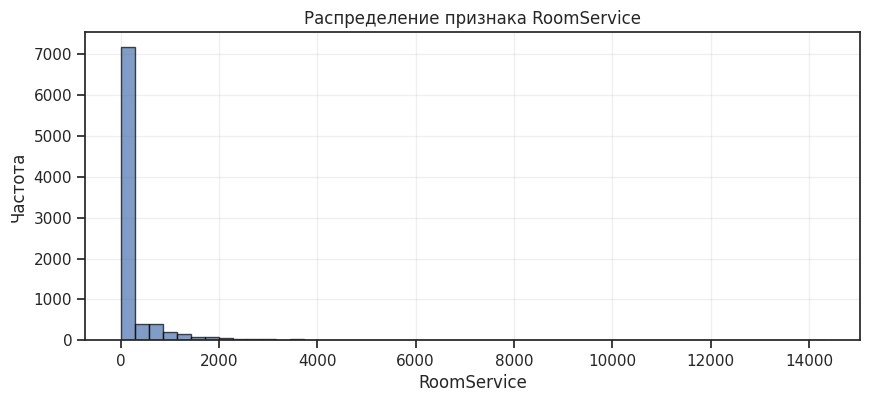

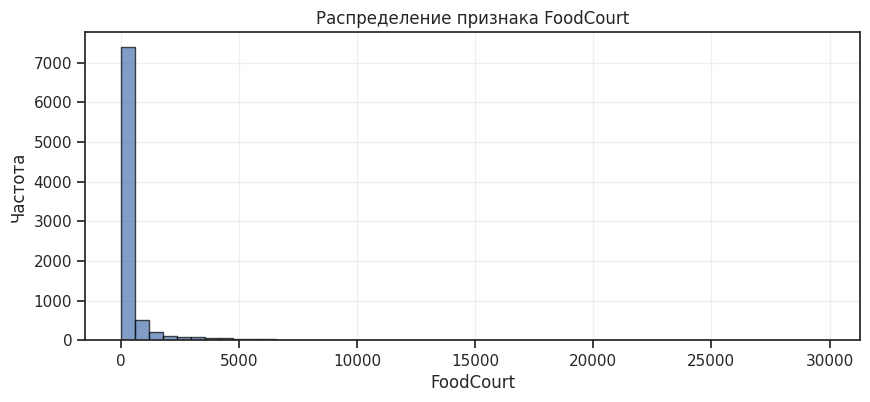

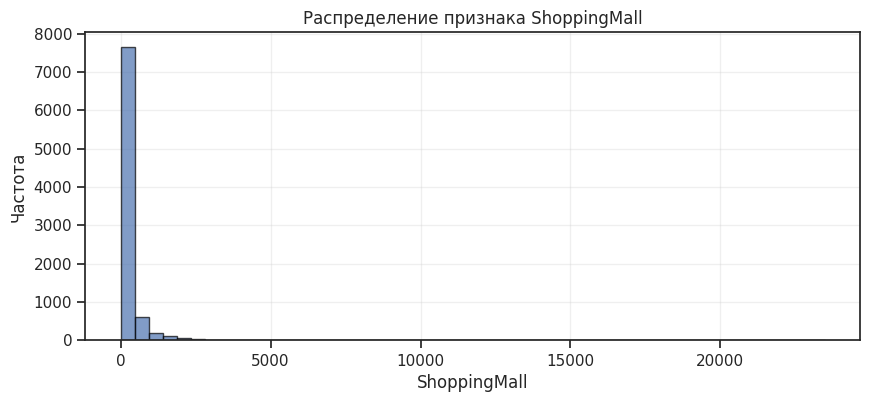

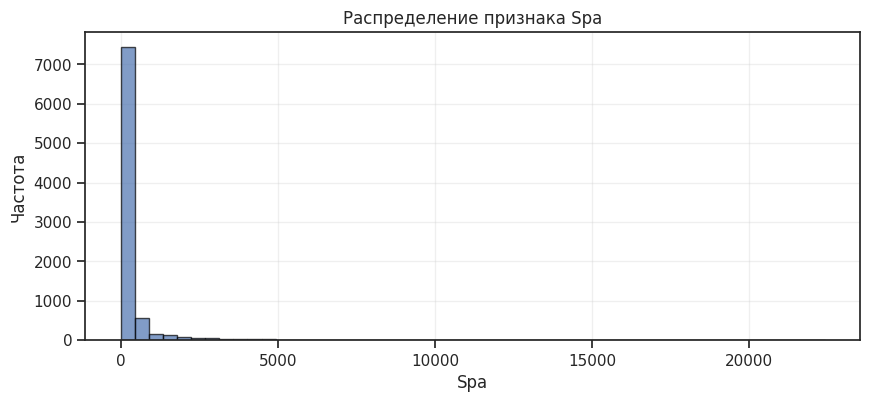

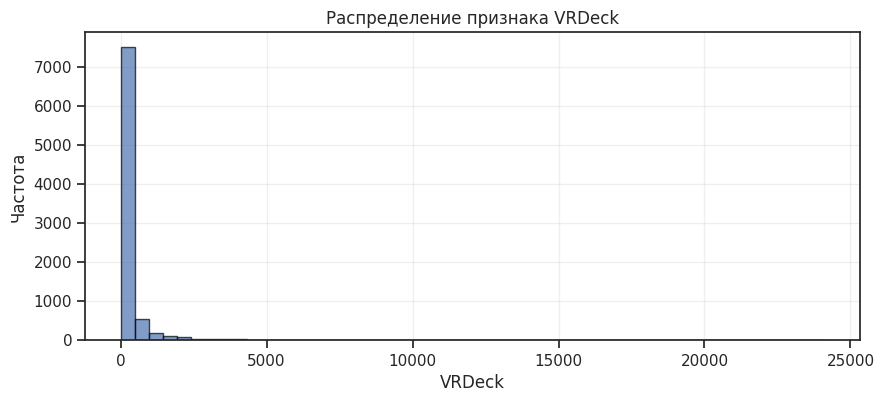

In [14]:
# Настройка размера графиков
plt.figure(figsize=(12, 8))

# Построение гистограмм
for col in data_num:
    plt.figure(figsize=(10, 4))
    plt.hist(sample_data[col].dropna(), bins=50, edgecolor='black', alpha=0.7)  # dropna() убирает пропуски
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.title(f'Распределение признака {col}')
    plt.grid(True, alpha=0.3)
    plt.show()

In [16]:
# Проверка пропусков
print("Пропуски после обработки:")
print(sample_data.isnull().sum())
print(f"\nВсего пропусков: {sample_data.isnull().sum().sum()}")

Пропуски после обработки:
PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin             0
Destination       0
Age               0
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
dtype: int64

Всего пропусков: 200


In [17]:

sample_data['Name'] = sample_data['Name'].fillna('Unknown')

print(sample_data.isnull().sum())

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64


In [18]:
# Все категориальные колонки
cat_cols_all = []

for col in sample_data.columns:
    dt = str(sample_data[col].dtype)
    if dt == 'object':
        cat_cols_all.append(col)
        print(f'Категориальная колонка: {col}, тип: {dt}')

print(f"\nВсего категориальных колонок: {len(cat_cols_all)}")
print(cat_cols_all)

# Посмотрим уникальные значения в каждой
for col in cat_cols_all:
    print(f"\n{col}:")
    print(f"Уникальных значений: {sample_data[col].nunique()}")
    print(f"Примеры: {sample_data[col].unique()[:5]}")

Категориальная колонка: PassengerId, тип: object
Категориальная колонка: HomePlanet, тип: object
Категориальная колонка: Cabin, тип: object
Категориальная колонка: Destination, тип: object
Категориальная колонка: Name, тип: object

Всего категориальных колонок: 5
['PassengerId', 'HomePlanet', 'Cabin', 'Destination', 'Name']

PassengerId:
Уникальных значений: 8693
Примеры: ['0001_01' '0002_01' '0003_01' '0003_02' '0004_01']

HomePlanet:
Уникальных значений: 3
Примеры: ['Europa' 'Earth' 'Mars']

Cabin:
Уникальных значений: 6561
Примеры: ['B/0/P' 'F/0/S' 'A/0/S' 'F/1/S' 'F/0/P']

Destination:
Уникальных значений: 3
Примеры: ['TRAPPIST-1e' 'PSO J318.5-22' '55 Cancri e']

Name:
Уникальных значений: 8474
Примеры: ['Maham Ofracculy' 'Juanna Vines' 'Altark Susent' 'Solam Susent'
 'Willy Santantines']


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
sample_data['Transported_encoded'] = le.fit_transform(sample_data['Transported'])
# False -> 0, True -> 1

In [21]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols = ['HomePlanet', 'Destination']
X_cat = sample_data[cat_cols]

oe = OrdinalEncoder()
X_cat_encoded = oe.fit_transform(X_cat)


In [22]:
# Добавляем новые колонки, старые оставляем
sample_data[['HomePlanet_enc', 'Destination_enc']] = X_cat_encoded

# Проверяем
print(sample_data[['HomePlanet', 'Destination', 'HomePlanet_enc', 'Destination_enc']].head())

  HomePlanet  Destination  HomePlanet_enc  Destination_enc
0     Europa  TRAPPIST-1e             1.0              2.0
1      Earth  TRAPPIST-1e             0.0              2.0
2     Europa  TRAPPIST-1e             1.0              2.0
3     Europa  TRAPPIST-1e             1.0              2.0
4      Earth  TRAPPIST-1e             0.0              2.0


In [25]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)  # вместо sparse=False
homeplanet_ohe = ohe.fit_transform(sample_data[['HomePlanet']])


print("Форма закодированных данных:", homeplanet_ohe.shape)
print("Названия колонок:", ohe.get_feature_names_out(['HomePlanet']))

Форма закодированных данных: (8693, 3)
Названия колонок: ['HomePlanet_Earth' 'HomePlanet_Europa' 'HomePlanet_Mars']


In [26]:
# Посмотрим первые строки
print(homeplanet_ohe[:10])  # первые 10 строк

[[0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]


In [27]:
# Создаем DataFrame с закодированными данными
homeplanet_encoded_df = pd.DataFrame(
    homeplanet_ohe,
    columns=['HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars'],
    index=sample_data.index
)

# Добавляем к исходным данным
sample_data = pd.concat([sample_data, homeplanet_encoded_df], axis=1)

# удалить исходную колонку HomePlanet
#sample_data = sample_data.drop('HomePlanet', axis=1)

# Проверяем
print(sample_data.head())

  PassengerId HomePlanet  CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa      False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth      False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa      False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa      False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth      False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  Transported_encoded  HomePlanet_enc  Destination_enc  \
0        False            

In [28]:
# Числовые признаки в вашем датасете
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Посмотрим статистику ДО масштабирования
print("ДО масштабирования:")
print(sample_data[num_cols].describe())

ДО масштабирования:
               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8693.000000   8693.000000   8693.000000   8693.000000   8693.000000   
mean     28.790291    220.009318    448.434027    169.572300    304.588865   
std      14.341404    660.519050   1595.790627    598.007164   1125.562559   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      20.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      37.000000     41.000000     61.000000     22.000000     53.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck  
count   8693.000000  
mean     298.261820  
std     1134.126417  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       40.000000  
max    24133.000000  


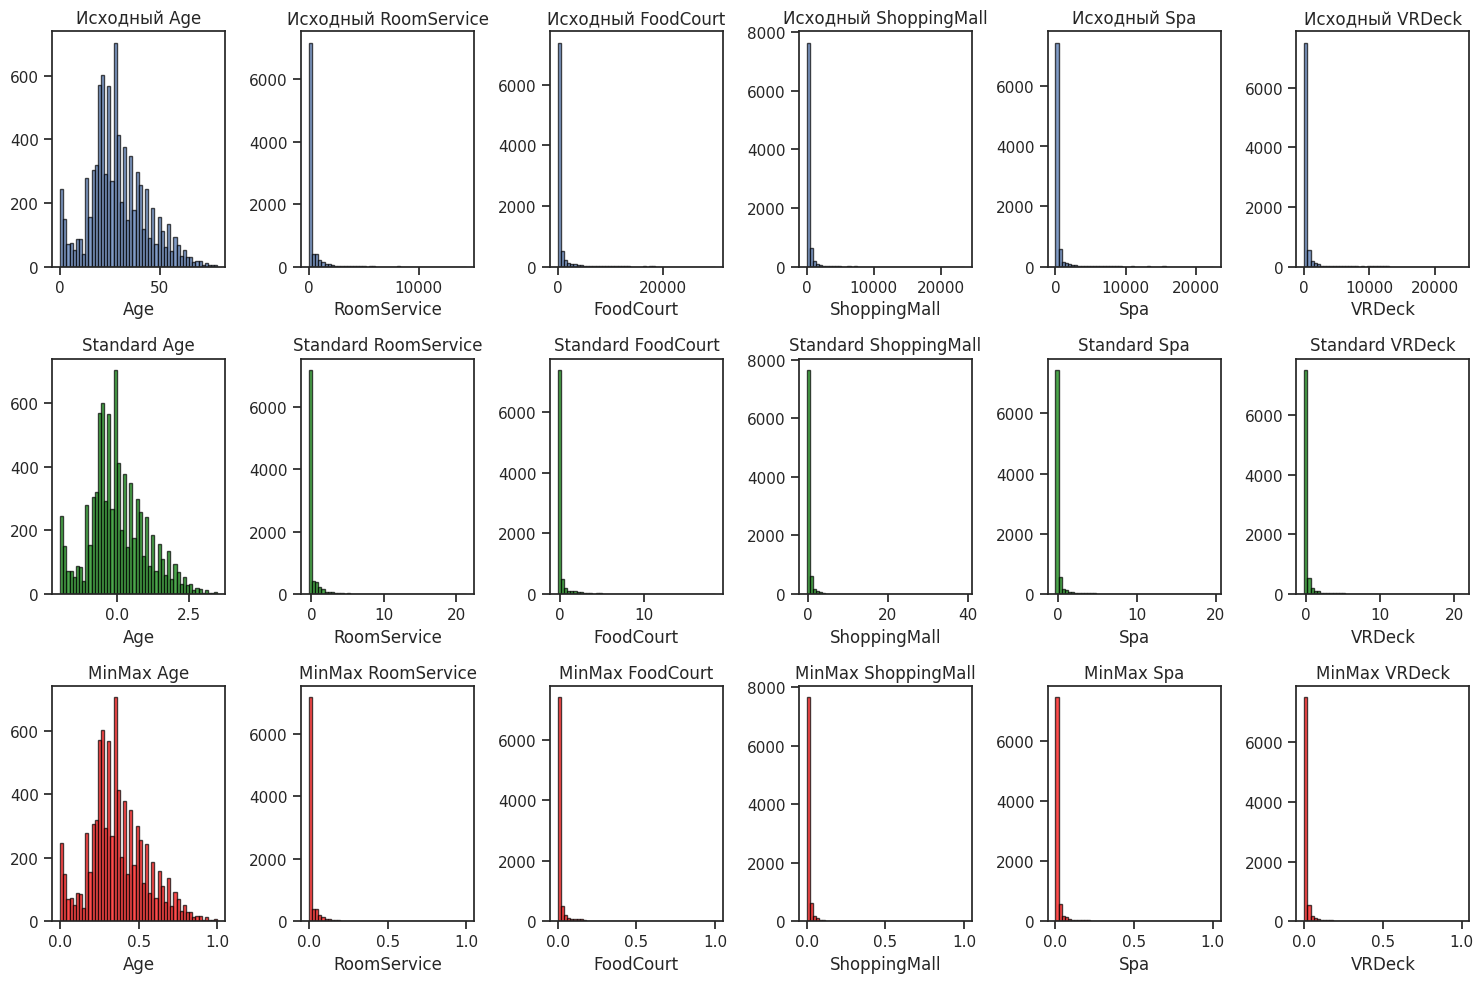

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Исходные данные
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 6, i)
    plt.hist(sample_data[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    plt.title(f'Исходный {col}')
    plt.xlabel(col)

# 2. StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(sample_data[num_cols])

for i, col in enumerate(num_cols, 7):  # начинаем с 7й позиции
    plt.subplot(3, 6, i)
    plt.hist(scaled_data[:, i-7], bins=50, edgecolor='black', alpha=0.7, color='green')
    plt.title(f'Standard {col}')
    plt.xlabel(col)

# 3. MinMaxScaler
minmax_scaler = MinMaxScaler()
minmax_data = minmax_scaler.fit_transform(sample_data[num_cols])

for i, col in enumerate(num_cols, 13):  # начинаем с 13й позиции
    plt.subplot(3, 6, i)
    plt.hist(minmax_data[:, i-13], bins=50, edgecolor='black', alpha=0.7, color='red')
    plt.title(f'MinMax {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()